# Single-layer dynamic neural field

This notebook demonstrates a basic 1D dynamic neural field with two competing Gaussian inputs. The field implements the Amari equation with lateral inhibition.

We then extract target activations at the input positions and track the peak of the field over time. The peak activation trace drives a task dynamic equation, producing smooth tract variable trajectories.

In [16]:
from pyphonplan import DynamicField, Targets, TaskDynamics
from pyphonplan.viz import plot_field_heatmap, plot_field_surface, plot_target_activations

## Create the field

Set up a field spanning [-10, 10] (our phonetic parameter) with a sigmoidal threshold and an interaction kernel (local excitation, lateral inhibition, global inhibition). The parameter range `[-10, 10]` is arbitrary; it just helps for the current simulation to know that `0` is the midpoint of the range and it gives us some space to potentially vary the width of the inputs and kernel later. The choice of parameter range can either be in arbitrary units, or a more informed choice. `step_size` controls the spatial resolution (number of discrete points across the range).

Note that the kernel parameters are defined relative to the parameter range, as the values represent the width of excitatory and inhibitory forces. The below values have been tuned to show particular phenomena clearly and are not necessarily meant as reference values.


In [17]:
field = DynamicField(x_min=-10, x_max=10, step_size=0.1)
field.set_sigmoid(beta=1.5, threshold=0.0)
field.set_kernel(c_exc=2, c_inh=1, c_global=0.5, sigma_exc=1.0, sigma_inh=2.0, expand=3.0)

### Sigmoid and kernel

The sigmoid gates which parts of the field contribute to self-excitation. You can change the shape and threshold location using the `beta` and `threshold` values in `set_sigmoid`.

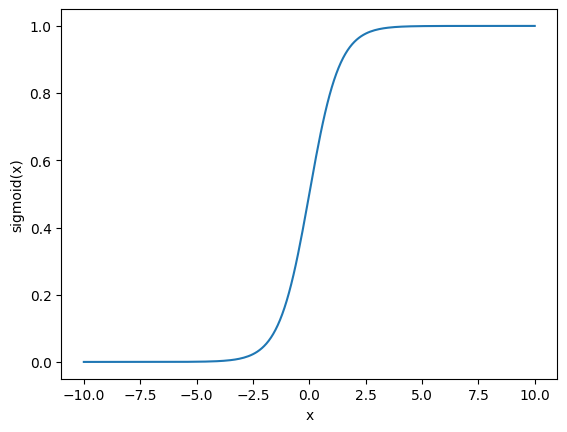

In [18]:
field.plot_sigmoid();

The kernel determines the spatial pattern of lateral interactions, showing a 'Mexican hat'-style pattern. If you're interested in learning more, try tweaking the parameters in `set_kernel` and see how this plot changes.

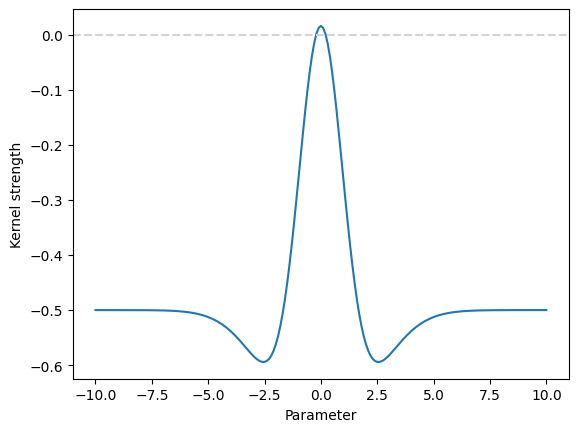

In [19]:
field.plot_kernel();

## Add inputs

We add two Gaussian inputs to the field at spatial locations `-5` and `+5`. Both inputs have the same amplitude, but the amplitudes can vary if needed. `input1` is active between time steps [50, 150], while `input2` is active between [100, 200]. Let's assume for now that these values represent milliseconds and they are integer values. Assuming integer values in the dynamic field simplifies some later analyses, such as identifying peak activations over time.

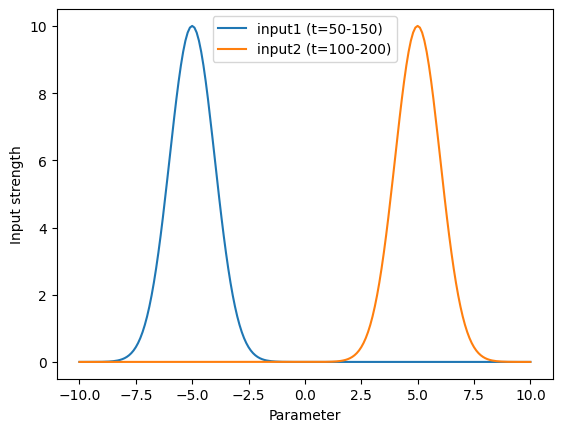

In [20]:
field.add_input("input1", amplitude=10, position=-5, width=1.0, start=50, end=150)
field.add_input("input2", amplitude=10, position=5, width=1.0, start=100, end=200)
field.plot_inputs();

## Solve the field

Now we can solve the dynamic field equation, which integrates the above inputs and the sigmoid and interaction kernel. We add a small amount of noise (`noise=1.0`), where larger values correspond to greater random noise. The randomness will be re-generated on every run; to fix the randomness, pass `rng=np.random.default_rng(42)` to `solve()`, and choose your favourite number instead of `42`.

In [21]:
field.solve(t_start=0, t_end=250, dt=1, tau=25.0, h=-2.0, noise=1.0)

## Visualise field activation

`PyPhonPlan` has two default ways of visualizing DNFs. The heatmap shows activation over time (x-axis) and space (y-axis). The red line shows the point at which activation crosses zero, and the white dashed line tracks the spatial position corresponding to peak activation at each time step. We can see a sudden shift in peak activation from `input1` to `input2` around 150 ms.

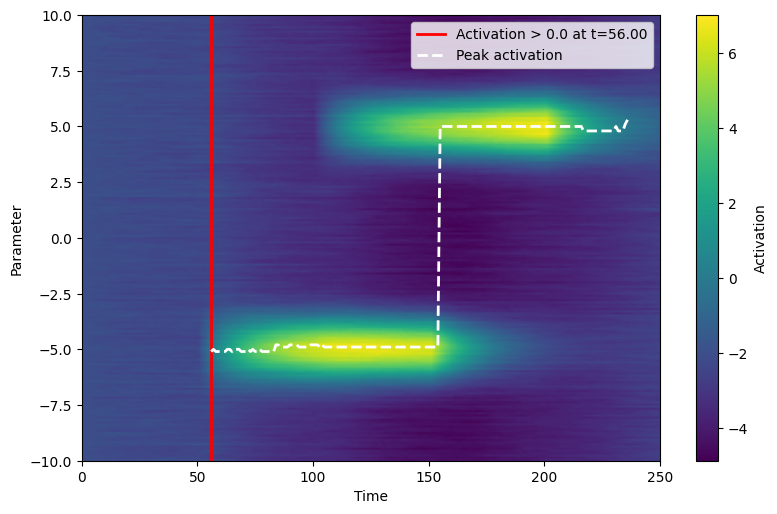

In [22]:
plot_field_heatmap(field.time, field.x, field.activation);

We can also visualise as a 3D surface, where the grey plane shows the user-defined activation threshold.

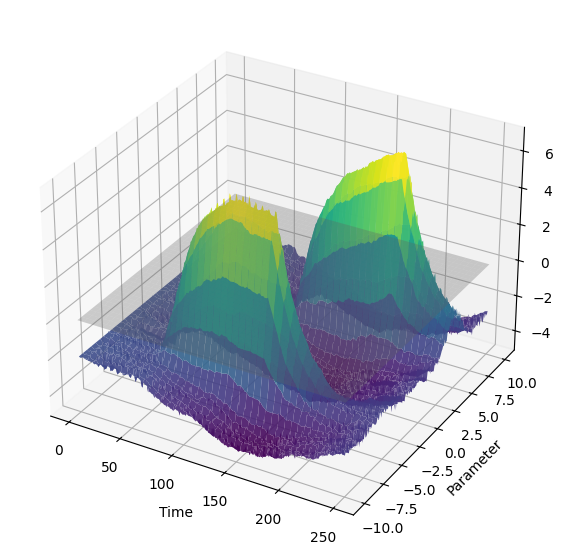

In [23]:
plot_field_surface(field.time, field.x, field.activation, threshold=0.0);

## Extract targets

In some cases, we might want to track the evolution of **specific** spatial values across the field. This doesn't necessarily correspond to the location of peak activation, which we examine later. In the above example, we specified inputs at `-5.0` and `5.0`, so let's extract activation time series at the two input positions and visualize over time.

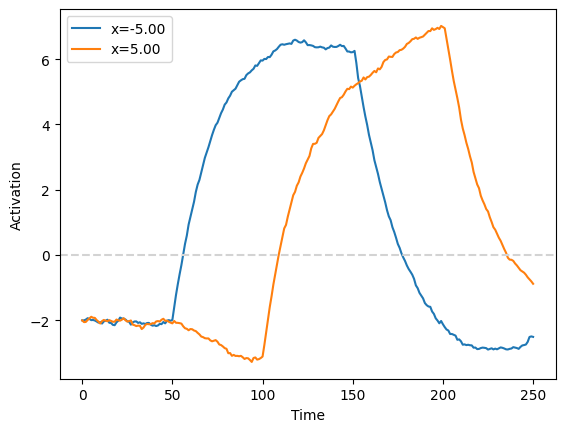

In [24]:
targets = Targets(field, positions=[-5.0, 5.0])
plot_target_activations(field.time, targets.traces);

### Peak activation tracking

We can also track the position and activation of the field's peak over time. We can see that peak activation follows a step function pattern (a switch from one target to another, plus a bit of noise due to the field's `noise` parameter). This trace can drive a task dynamic equation to produce smooth articulatory trajectories (see below). The first plot shows the spatial location of peak activation; the second plot shows amplitude of peak activation at each point in time.

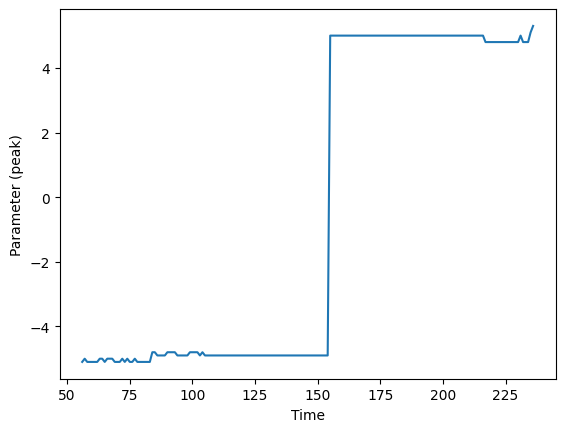

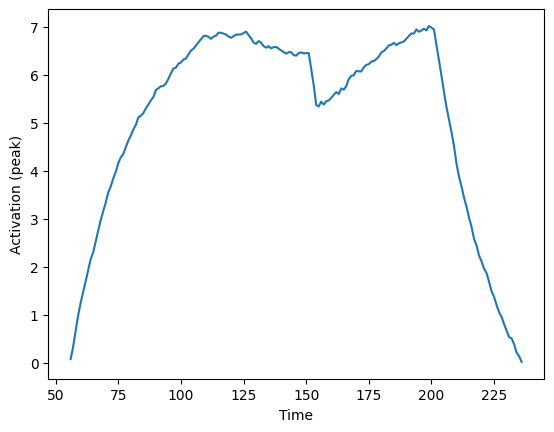

In [25]:
targets.peak_activation(plot=True);

## Animate field activation

An alternative method is to visualise the field as an activation distribution and animate how this changes over time. The following code writes to a GIF file, but if you change the extension to `.mp4` it will render as an mp4 video instead.

In [26]:
from pyphonplan.viz import animate_field
animate_field(field.time, field.x, field.activation, save_path="single_field.gif", show=False);

![Field activation animation](https://raw.githubusercontent.com/samkirkham/PyPhonPlan/main/examples/single_field.gif)

In [27]:
param_peak, act_peak, time = targets.peak_activation(above_threshold=True)

The `time_scale` parameter converts field time units to ODE seconds. The field uses integer time steps corresponding to milliseconds, so `time_scale=0.001` converts to seconds. Stiffness `k` must be tuned relative to this time scale; here `k=8000` is sufficient to reach targets within the input durations. In these examples, `k` is tuned to control how quickly the target is reached.

In [28]:
td = TaskDynamics()
td.solve_from_trace(time, param_peak, k=8000, time_scale=0.001)

### Articulatory trajectory

The tract variable trajectory and its absolute velocity. The position plot shows an initial position of zero, a transition to -5, and a second transition to +5. Note that as a critically-damped oscillator, the target will be reached asymptotically, meaning it will never truly reach the target but get closer and closer over time.

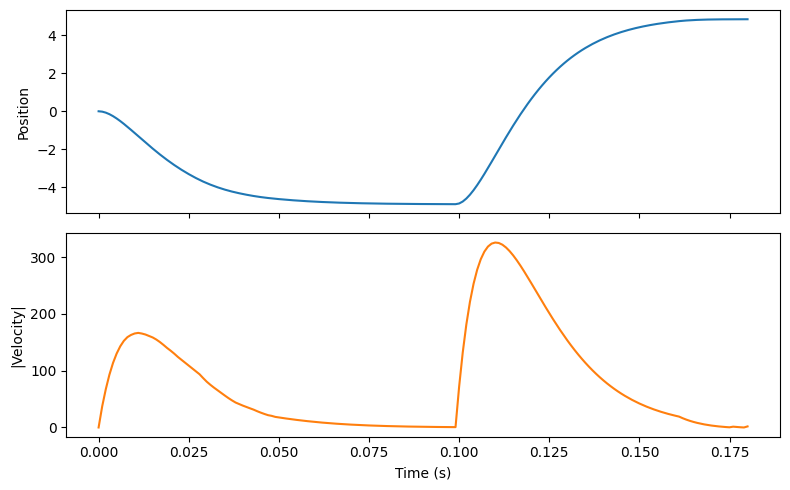

In [29]:
td.plot(abs_velocity=True);

Finally, we can also use `plot_params` to visualize the time-varying value of the target. This also works for other parameters; see `examples/tract_variables` for further details.

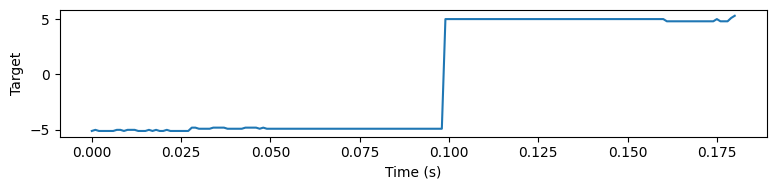

In [30]:
td.plot_params(params=["target"]);